# CodeReviewer Data Preprocessing

**Thesis:** Chain of Thought Supervision for Code Review Comment Generation
**Author:** Ayush Srivastava (24268798): MSc Artificial Intelligence, NCI

This notebook prepares the Python subset of the CodeReviewer dataset (Li et al., 2022)
for fine-tuning. It is organised as follows:

0. Setup
1. Data loading
2. Initial exploration
3. The metadata problem (missing language / repository fields)
4. Language recovery via a trained classifier
5. Exploration of the Python data
6. Filtering *(tentative: to be confirmed)*
7. Train / validation / test split *(tentative)*
8. Saving the final dataset



## 0. Setup

Imports, paths, and a small set of configuration constants kept in one place so the
notebook is easy to re-run and modify.


In [4]:
import json
import hashlib
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Plot styling (readable defaults)
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Setup complete.")

Setup complete.


In [5]:
# --- Paths -------------------------------------------------------------
# Notebook lives in <project>/notebooks/, data in <project>/data/raw/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR       = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Comment Generation = our main task (msg files)
CG_DIR  = RAW_DIR / "Comment_Generation"
# Diff Quality Estimation = used only to recover language labels (cls files)
DQE_DIR = RAW_DIR / "Diff_Quality_Estimation"

TRAIN_FILE = CG_DIR / "msg-train.jsonl"
VALID_FILE = CG_DIR / "msg-valid.jsonl"
TEST_FILE  = CG_DIR / "msg-test.jsonl"

# Quick existence check
for name, path in [("train", TRAIN_FILE), ("valid", VALID_FILE), ("test", TEST_FILE)]:
    print(f"{name:6s}: exists={path.exists()}  ({path})")

train : exists=True  (d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\raw\Comment_Generation\msg-train.jsonl)
valid : exists=True  (d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\raw\Comment_Generation\msg-valid.jsonl)
test  : exists=True  (d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\raw\Comment_Generation\msg-test.jsonl)


## 1. Data loading

Each file is in JSON Lines format (one JSON object per line). We load with a small helper
rather than `pandas.read_json`, because the `oldf` field contains full source files
(often 20k+ characters) and a plain list of dictionaries is far faster and lighter here.

Each sample has five fields:

| Field  | Meaning                                            |
|--------|----------------------------------------------------|
| `oldf` | the full source file *before* the change           |
| `patch`| the diff (the actual change, in `@@ ... @@` form)   |
| `msg`  | the reviewer's comment (our generation target)      |
| `id`   | sample id                                           |
| `y`    | label (always 1 in this task)                       |


In [6]:
def load_jsonl(path):
    """Load a JSON Lines file into a list of dictionaries."""
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


train = load_jsonl(TRAIN_FILE)
valid = load_jsonl(VALID_FILE)
test  = load_jsonl(TEST_FILE)

print(f"train : {len(train):,} rows")
print(f"valid : {len(valid):,} rows")
print(f"test  : {len(test):,} rows")
print(f"total : {len(train) + len(valid) + len(test):,} rows")

train : 117,739 rows
valid : 10,319 rows
test  : 10,169 rows
total : 138,227 rows


In [7]:
# Inspect one sample to understand the structure
sample = valid[0]
print("Fields:", list(sample.keys()))
print()
print("lang :", sample.get("lang"))
print("proj :", sample.get("proj"))
print("msg  :", sample.get("msg"))
print()
print("oldf (first 200 chars):")
print(sample["oldf"][:200])

Fields: ['patch', 'y', 'oldf', 'idx', 'id', 'msg', 'proj', 'lang']

lang : py
proj : inveniosoftware-invenio
msg  : Should we call it `is_list`?

oldf (first 200 chars):
# -*- coding: utf-8 -*-
#
# This file is part of Invenio.
# Copyright (C) 2012, 2013, 2014, 2015 CERN.
#
# Invenio is free software; you can redistribute it and/or
# modify it under the terms of the G


## 2. Initial exploration

A first look at dataset sizes and the label field before dealing with the metadata issue.


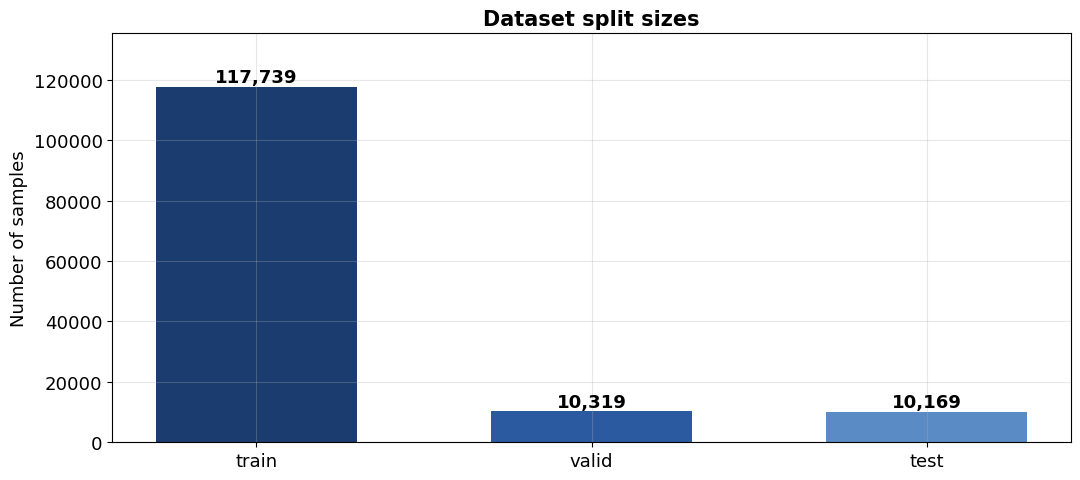

In [8]:
# Dataset split sizes
sizes = {"train": len(train), "valid": len(valid), "test": len(test)}

fig, ax = plt.subplots()
bars = ax.bar(sizes.keys(), sizes.values(),
              color=["#1a3c6e", "#2c5aa0", "#5a8bc4"], width=0.6)
for bar, val in zip(bars, sizes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1500,
            f"{val:,}", ha="center", fontweight="bold")
ax.set_ylabel("Number of samples")
ax.set_title("Dataset split sizes")
ax.set_ylim(0, max(sizes.values()) * 1.15)
plt.tight_layout()
plt.show()

In [9]:
# The label field y in the comment-generation task every sample has a comment,
# so y is always 1 and carries no signal for this task.
print("y value counts:")
print("  train:", Counter(r.get("y") for r in train))
print("  valid:", Counter(r.get("y") for r in valid))
print("  test :", Counter(r.get("y") for r in test))

y value counts:
  train: Counter({1: 117739})
  valid: Counter({1: 10319})
  test : Counter({1: 10169})


## 3. The metadata problem

The training file is missing the `lang` and `proj` fields that validation and test have.
This blocks two things we need:

- **Language filtering** we want only Python samples, but train has no `lang`.
- **Repository-level splitting** we want to avoid leakage, but train has no `proj`.

We confirm this below.


In [10]:
def field_coverage(rows, field):
    """Fraction of rows that contain a given field."""
    present = sum(1 for r in rows if field in r)
    return present, len(rows)


for field in ["lang", "proj"]:
    print(f"Field '{field}':")
    for name, rows in [("train", train), ("valid", valid), ("test", test)]:
        present, total = field_coverage(rows, field)
        print(f"  {name:6s}: {present:>7,} / {total:>7,} present")
    print()

Field 'lang':
  train :       0 / 117,739 present
  valid :  10,319 /  10,319 present
  test  :  10,169 /  10,169 present

Field 'proj':
  train :       0 / 117,739 present
  valid :  10,319 /  10,319 present
  test  :  10,169 /  10,169 present



**Observation:** `lang` and `proj` are present in validation and test, but completely
absent from training. We therefore need to *recover* the language labels for training.

(Several recovery routes were tried; matching on `id` and on file content from the
Code Refinement files proved unreliable. The reliable solution, below, is to train a
language classifier on the verified labels we do have.)


## 4. Language recovery via a trained classifier

We have ~56k code files *with* verified language labels (from the cls and valid/test
files). We use these to train a simple, fast language classifier
(character n-gram TF-IDF + LinearSVC), then apply it to the unlabelled training files.

**Why a classifier and not a library?** An off-the-shelf detector (pygments) gave only
~41% precision on Python here, because it confuses Python-like syntax. A classifier
trained on this specific data reaches ~99% precision.


In [11]:
def md5(text):
    """Stable hash of a string, used to dedupe files by content."""
    return hashlib.md5(text.encode("utf-8", errors="ignore")).hexdigest()


def collect_labelled(paths):
    """Collect (code, language) pairs from files that have a 'lang' field.
    Deduplicated by file content so the same file is not counted twice."""
    seen = set()
    codes, langs = [], []
    for path in paths:
        if not path.exists():
            continue
        with open(path, encoding="utf-8") as f:
            for line in f:
                s = json.loads(line)
                oldf, lang = s.get("oldf"), s.get("lang")
                if oldf and lang:
                    key = md5(oldf)
                    if key not in seen:
                        seen.add(key)
                        codes.append(oldf)
                        langs.append(lang)
    return codes, langs


labelled_paths = [
    DQE_DIR / "cls-train-chunk-1.jsonl",
    DQE_DIR / "cls-test.jsonl",
    DQE_DIR / "cls-valid.jsonl",
    VALID_FILE,
    TEST_FILE,
]

X_code, y_lang = collect_labelled(labelled_paths)
print(f"Labelled examples: {len(X_code):,}")
print("Language distribution:")
for lang, count in Counter(y_lang).most_common():
    print(f"  {lang:6s}: {count:>6,}")

Labelled examples: 56,477
Language distribution:
  go    : 14,825
  py    : 10,694
  java  :  9,092
  js    :  5,905
  cpp   :  4,663
  .cs   :  3,598
  rb    :  3,276
  php   :  2,278
  c     :  2,146


### 4.1 Skipping licence headers

Many source files start with a long licence/comment block that looks similar across
languages and confuses the classifier. We strip the leading comment block and keep the
first part of the actual code for classification.


In [12]:
COMMENT_STARTS = ("#", "//", "/*", "*", "<!--", ";", '"""', "'''")


def get_code_sample(oldf, length=1500):
    """Skip the leading comment/licence block, return the first `length` chars of code."""
    lines = oldf.split("\n")
    start = 0
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped and not stripped.startswith(COMMENT_STARTS):
            start = i
            break
    return "\n".join(lines[start:])[:length]

### 4.2 Train and evaluate the classifier

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Clean the labelled code (skip licence headers), then split
X_clean = [get_code_sample(c) for c in X_code]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean, y_lang, test_size=0.2, random_state=RANDOM_SEED, stratify=y_lang
)

lang_clf = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 3),
                              max_features=5000, sublinear_tf=True)),
    ("svc",   LinearSVC(class_weight="balanced", max_iter=2000)),
])

lang_clf.fit(X_tr, y_tr)
print("Held-out classification report:\n")
print(classification_report(y_te, lang_clf.predict(X_te), digits=3))

Held-out classification report:

              precision    recall  f1-score   support

         .cs      0.986     1.000     0.993       720
           c      0.943     0.958     0.950       429
         cpp      0.986     0.982     0.984       933
          go      0.995     0.989     0.992      2965
        java      0.989     0.988     0.989      1818
          js      0.982     0.992     0.987      1181
         php      0.976     0.982     0.979       456
          py      0.992     0.983     0.987      2139
          rb      0.970     0.985     0.977       655

    accuracy                          0.987     11296
   macro avg      0.980     0.984     0.982     11296
weighted avg      0.987     0.987     0.987     11296



### 4.3 Apply the classifier to the training set

In [14]:
# Predict language for every training row
train_codes = [get_code_sample(r.get("oldf", "")) for r in train]
train_preds = lang_clf.predict(train_codes)
for row, pred in zip(train, train_preds):
    row["lang_pred"] = pred

print("Predicted language distribution (full train):")
for lang, count in Counter(train_preds).most_common():
    print(f"  {lang:6s}: {count:>7,} ({count / len(train_preds) * 100:.1f}%)")

Predicted language distribution (full train):
  py    :  33,579 (28.5%)
  java  :  22,189 (18.8%)
  go    :  16,841 (14.3%)
  js    :  10,933 (9.3%)
  rb    :   8,660 (7.4%)
  .cs   :   8,321 (7.1%)
  php   :   6,879 (5.8%)
  cpp   :   5,550 (4.7%)
  c     :   4,787 (4.1%)


### 4.4 Post-rules to remove obvious misclassifications

The classifier occasionally labels Go / Java / C# / Ruby files as Python when their
opening lines overlap with Python patterns. These are easy to catch with a few
deterministic rules (Python never starts with `package`, `using System`, `require`, etc.).


In [15]:
def looks_non_python(code):
    """Deterministic checks for clearly non-Python files."""
    s = code.lstrip()
    if s.startswith("package "):                       # Go / Java
        return True
    if "import static " in code[:200]:                 # Java
        return True
    if s.startswith(("public class", "private class", "func ")):  # Java / Go
        return True
    if s.startswith(("using System", "using namespace")):         # C# / C++
        return True
    if s.startswith(("require ", "require\"", "require'")):       # Ruby
        return True
    if "RSpec." in code[:200]:                         # Ruby
        return True
    if s.startswith(("<%", "<?", "<!")):               # templates
        return True
    if s.startswith("Name:") and "Version:" in code[:200]:  # RPM spec
        return True
    return False


python_train = [
    r for r in train
    if r["lang_pred"] == "py"
    and not looks_non_python(get_code_sample(r.get("oldf", "")))
]

before = sum(1 for r in train if r["lang_pred"] == "py")
print(f"Predicted Python      : {before:,}")
print(f"After post-rules clean: {len(python_train):,}")
print(f"Removed               : {before - len(python_train):,}")

Predicted Python      : 33,579
After post-rules clean: 29,074
Removed               : 4,505


**Validation:** a manual check of 1,000 of these predicted-Python samples showed
~99% precision (only ~8-9 non-Python out of 1,000), consistent with the held-out
classifier accuracy. This is the recommended Python training set.


## 5. Exploration of the Python data

Now we look at the distributions that matter for filtering (Section 6): comment length
and code-file size. The proposal's filter thresholds are marked on the plots.


In [16]:
python_valid = [r for r in valid if r.get("lang") == "py"]
python_test  = [r for r in test  if r.get("lang") == "py"]

print(f"Python train: {len(python_train):,}")
print(f"Python valid: {len(python_valid):,}")
print(f"Python test : {len(python_test):,}")
print(f"Python total: {len(python_train) + len(python_valid) + len(python_test):,}")

Python train: 29,074
Python valid: 1,420
Python test : 1,403
Python total: 31,897


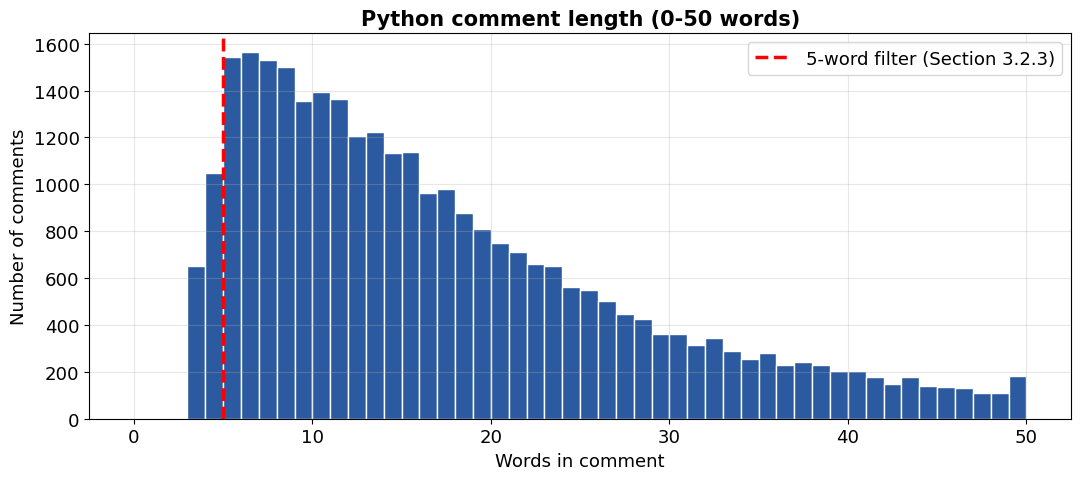

Comments < 5 words: 5.3%


In [17]:
# Comment length distribution (in words)
def word_count(text):
    return len(str(text).split())

all_python = python_train + python_valid + python_test
comment_words = np.array([word_count(r.get("msg", "")) for r in all_python])

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(comment_words[comment_words <= 50], bins=range(0, 51),
        color="#2c5aa0", edgecolor="white")
ax.axvline(5, color="red", linestyle="--", linewidth=2.5,
           label="5-word filter (Section 3.2.3)")
ax.set_xlabel("Words in comment")
ax.set_ylabel("Number of comments")
ax.set_title("Python comment length (0-50 words)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Comments < 5 words: {(comment_words < 5).mean() * 100:.1f}%")

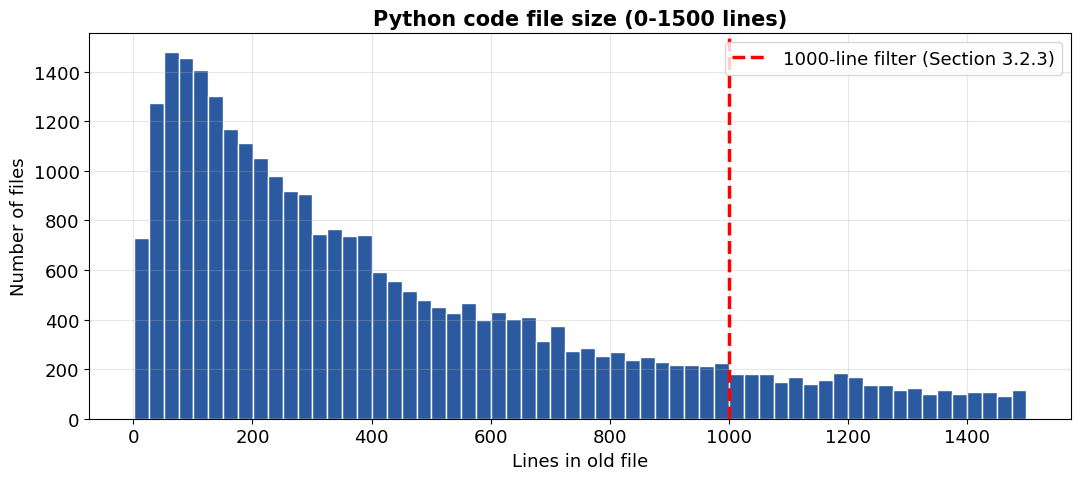

Files > 1000 lines: 20.8%


In [18]:
# Code file size distribution (in lines)
def line_count(text):
    return str(text).count("\n") + 1

code_lines = np.array([line_count(r.get("oldf", "")) for r in all_python])

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(code_lines[code_lines <= 1500], bins=60, color="#2c5aa0", edgecolor="white")
ax.axvline(1000, color="red", linestyle="--", linewidth=2.5,
           label="1000-line filter (Section 3.2.3)")
ax.set_xlabel("Lines in old file")
ax.set_ylabel("Number of files")
ax.set_title("Python code file size (0-1500 lines)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Files > 1000 lines: {(code_lines > 1000).mean() * 100:.1f}%")

## 6. Filtering *(need confirmation)*

The proposal (Section 3.2.3) lists five filters. Below we **measure the impact** of each
one (how many samples it would remove) without committing to a final pipeline yet.
The exact thresholds will be confirmed.

1. Remove comments shorter than 5 words
2. Remove generic comments ("approved", "ship it", etc.)
3. Remove files longer than 1000 lines


In [19]:
# Measure the impact of each filter on the Python TRAIN set (no changes applied yet).
GENERIC_COMMENTS = {
    "lgtm", "ok", "okay", "approved", "ship it", "done", "thanks",
    "nit", "+1", "looks good", "looks good to me", "good", "fixed",
}


def is_generic(msg):
    return msg.strip().lower().rstrip(".!") in GENERIC_COMMENTS


n = len(python_train)
short    = sum(1 for r in python_train if word_count(r.get("msg", "")) < 5)
generic  = sum(1 for r in python_train if is_generic(r.get("msg", "")))
too_long = sum(1 for r in python_train if line_count(r.get("oldf", "")) > 1000)

print(f"Python train total           : {n:,}")
print(f"  (1) comments < 5 words     : {short:,}  ({short / n * 100:.1f}%)")
print(f"  (2) generic comments       : {generic:,}  ({generic / n * 100:.1f}%)")
print(f"  (3) files > 1000 lines     : {too_long:,}  ({too_long / n * 100:.1f}%)")
print(f"  (4) bot commits            : metadata not available — TBD")
print(f"  (5) near-duplicates        : TBD (TF-IDF, to confirm threshold)")

Python train total           : 29,074
  (1) comments < 5 words     : 1,522  (5.2%)
  (2) generic comments       : 0  (0.0%)
  (3) files > 1000 lines     : 6,082  (20.9%)
  (4) bot commits            : metadata not available — TBD
  (5) near-duplicates        : TBD (TF-IDF, to confirm threshold)


## 7. Train / validation / test split *(tentative)*

We use the official CodeReviewer splits (train / valid / test files) as released.

**Important caveat: repository overlap:** validation and test share repositories
(212 of 212 test repositories also appear in validation), so the official splits are
**not repository-disjoint**. This is a known source of leakage (Liu et al., 2018).

Because the study is a *controlled comparison* (Setup A vs Setup B trained on the same
data), this leakage affects both setups equally and largely cancels out for the main
result. It will be documented as a limitation.


In [20]:
# Repository overlap check (validation vs test, where proj is available)
valid_repos = {r["proj"] for r in python_valid if "proj" in r}
test_repos  = {r["proj"] for r in python_test  if "proj" in r}
overlap = valid_repos & test_repos

print(f"Valid Python repos: {len(valid_repos)}")
print(f"Test Python repos : {len(test_repos)}")
print(f"Overlap           : {len(overlap)} of {len(test_repos)} test repos")
print(f"Repository-disjoint? {'NO' if overlap else 'YES'}")

Valid Python repos: 29
Test Python repos : 28
Overlap           : 28 of 28 test repos
Repository-disjoint? NO


## 8. Saving the dataset

save the Python training set (with predicted language) so the classifier does not
need to be re-run. Validation and test Python subsets are saved as well. Filtering is
**not** applied here that step is finalised after the discussion.


In [21]:
def save_jsonl(rows, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
    print(f"Saved {len(rows):,} rows -> {path}")


save_jsonl(python_train, PROCESSED_DIR / "python_train.jsonl")
save_jsonl(python_valid, PROCESSED_DIR / "python_valid.jsonl")
save_jsonl(python_test,  PROCESSED_DIR / "python_test.jsonl")

Saved 29,074 rows -> d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\processed\python_train.jsonl
Saved 1,420 rows -> d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\processed\python_valid.jsonl
Saved 1,403 rows -> d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\processed\python_test.jsonl


---

### Summary

| Stage                | Result                                             |
|----------------------|----------------------------------------------------|
| Raw dataset          | 138,227 samples (train 117,739 / valid / test)     |
| Problem              | train has no `lang` / `proj` fields                 |
| Language recovery    | classifier, 98.9% held-out, ~99% precision          |
| Python data          | train 29,074 / valid 1,420 / test 1,403             |
| Filtering            | impact measured; thresholds **tentative**           |
| Split                | official splits; repo-overlap noted as limitation   |




## Only unique code

In [22]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report


def collect_labelled_with_repo(paths):
    seen = set()
    codes, langs, repos = [], [], []
    for path in paths:
        if not path.exists(): continue
        with open(path, encoding="utf-8") as f:
            for line in f:
                s = json.loads(line)
                oldf, lang, proj = s.get("oldf"), s.get("lang"), s.get("proj")
                if oldf and lang and proj: 
                    key = md5(oldf)
                    if key not in seen:
                        seen.add(key)
                        codes.append(oldf); langs.append(lang); repos.append(proj)
    return codes, langs, repos

Xc, yc, repos = collect_labelled_with_repo(labelled_paths)
print(f"Examples with repo info: {len(Xc):,}")


gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(Xc, yc, groups=repos))

X_tr = [get_code_sample(Xc[i]) for i in tr_idx]
X_te = [get_code_sample(Xc[i]) for i in te_idx]
y_tr = [yc[i] for i in tr_idx]
y_te = [yc[i] for i in te_idx]


train_repos = {repos[i] for i in tr_idx}
test_repos  = {repos[i] for i in te_idx}
print(f"Repo overlap between train/test: {len(train_repos & test_repos)} (should be 0)")

clf2 = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2,3),
                              max_features=5000, sublinear_tf=True)),
    ("svc", LinearSVC(class_weight="balanced", max_iter=2000)),
])
clf2.fit(X_tr, y_tr)
print("\nREPO-DISJOINT held-out report:")
print(classification_report(y_te, clf2.predict(X_te), digits=3))

Examples with repo info: 56,477
Repo overlap between train/test: 0 (should be 0)

REPO-DISJOINT held-out report:
              precision    recall  f1-score   support

         .cs      0.716     0.843     0.774       344
           c      0.830     0.784     0.807       218
         cpp      0.893     0.933     0.913      1025
          go      0.996     0.999     0.998      4263
        java      0.422     0.850     0.564       847
          js      0.913     0.993     0.951       404
         php      0.978     0.779     0.867       285
          py      0.961     0.619     0.753      2681
          rb      0.967     0.974     0.970      1491

    accuracy                          0.877     11558
   macro avg      0.853     0.864     0.844     11558
weighted avg      0.918     0.877     0.883     11558



## using only comment generation test and valid data


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# --- TRAIN data: sirf cls files se (msg-valid/test ko bilkul alag rakho) ---
cls_only_paths = [
    DQE_DIR / "cls-train-chunk-1.jsonl",
    DQE_DIR / "cls-test.jsonl",
    DQE_DIR / "cls-valid.jsonl",
]
X_train_code, y_train_lang = collect_labelled(cls_only_paths)
X_train = [get_code_sample(c) for c in X_train_code]
print(f"Train (cls only): {len(X_train):,}")

# --- TEST data: sirf Comment_Generation valid + test (native lang) ---
test_code, test_lang = [], []
for path in [VALID_FILE, TEST_FILE]:
    with open(path, encoding="utf-8") as f:
        for line in f:
            s = json.loads(line)
            if s.get("oldf") and s.get("lang"):
                test_code.append(get_code_sample(s["oldf"]))
                test_lang.append(s["lang"])
print(f"Test (msg valid+test): {len(test_code):,}")

# --- Train classifier on cls, test on msg ---
clf3 = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2,3),
                              max_features=5000, sublinear_tf=True)),
    ("svc", LinearSVC(class_weight="balanced", max_iter=2000)),
])
clf3.fit(X_train, y_train_lang)

pred = clf3.predict(test_code)
print(f"\nAccuracy on msg valid+test: {accuracy_score(test_lang, pred)*100:.1f}%")
print("\nReport:")
print(classification_report(test_lang, pred, digits=3))

Train (cls only): 56,477
Test (msg valid+test): 19,555

Accuracy on msg valid+test: 96.5%

Report:
              precision    recall  f1-score   support

         .cs      0.995     1.000     0.997      1277
           c      0.915     0.976     0.945       930
         cpp      0.995     0.996     0.996      1455
          go      0.994     0.976     0.985      5508
        java      0.974     0.952     0.963      3190
          js      0.932     0.933     0.932      1866
         php      0.946     0.989     0.967       840
          py      0.960     0.949     0.955      2711
          rb      0.896     0.942     0.918      1778

    accuracy                          0.965     19555
   macro avg      0.956     0.968     0.962     19555
weighted avg      0.966     0.965     0.965     19555



In [24]:
import json
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

#  Comment_Generation valid + test JODO (dono mein lang + proj hai)
cg_code, cg_lang, cg_repo = [], [], []
seen = set()
for path in [VALID_FILE, TEST_FILE]:
    with open(path, encoding="utf-8") as f:
        for line in f:
            s = json.loads(line)
            oldf, lang, proj = s.get("oldf"), s.get("lang"), s.get("proj")
            if oldf and lang and proj:
                key = md5(oldf)
                if key not in seen:          # dedup
                    seen.add(key)
                    cg_code.append(oldf)
                    cg_lang.append(lang)
                    cg_repo.append(proj)

print(f"Comment_Generation labeled (valid+test, deduped): {len(cg_code):,}")
print(f"Unique repos: {len(set(cg_repo))}")

# REPO-DISJOINT split (ek repo poora ek taraf) 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(cg_code, cg_lang, groups=cg_repo))

X_tr = [get_code_sample(cg_code[i]) for i in tr_idx]
X_te = [get_code_sample(cg_code[i]) for i in te_idx]
y_tr = [cg_lang[i] for i in tr_idx]
y_te = [cg_lang[i] for i in te_idx]

# Confirm repo-disjoint
train_repos = {cg_repo[i] for i in tr_idx}
test_repos  = {cg_repo[i] for i in te_idx}
print(f"Repo overlap train/test: {len(train_repos & test_repos)} (should be 0)")
print(f"Train: {len(X_tr):,}  Test: {len(X_te):,}")

#  Train + evaluate 
clf = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2,3),
                              max_features=5000, sublinear_tf=True)),
    ("svc", LinearSVC(class_weight="balanced", max_iter=2000)),
])
clf.fit(X_tr, y_tr)

pred = clf.predict(X_te)
print(f"\nAccuracy (repo-disjoint, Comment_Generation only): {accuracy_score(y_te, pred)*100:.1f}%")
print("\nClassification report:")
print(classification_report(y_te, pred, digits=3))

Comment_Generation labeled (valid+test, deduped): 18,192
Unique repos: 216
Repo overlap train/test: 0 (should be 0)
Train: 14,420  Test: 3,772

Accuracy (repo-disjoint, Comment_Generation only): 92.8%

Classification report:
              precision    recall  f1-score   support

         .cs      0.979     0.983     0.981       286
           c      0.978     0.489     0.652       180
         cpp      0.358     0.437     0.394        87
          go      0.995     0.999     0.997      1711
        java      0.948     0.815     0.876       465
          js      0.994     0.953     0.973       557
         php      0.994     0.994     0.994       169
          py      0.083     1.000     0.154        14
          rb      0.977     0.970     0.974       303

    accuracy                          0.928      3772
   macro avg      0.812     0.849     0.777      3772
weighted avg      0.968     0.928     0.942      3772



In [ ]:
import numpy as np

def line_count(text):
    return str(text).count("\n") + 1


lines = np.array([line_count(r.get("oldf", "")) for r in python_train])

print(f"Total Python train: {len(lines):,}\n")
print("Agar threshold ye ho, toh kitna data hatega:\n")
print(f"{'Threshold':>10} {'Removed':>10} {'% Removed':>12} {'Kept':>10}")
print("-" * 46)
for thr in [1000, 1500, 2000, 2500, 3000, 4000, 5000]:
    removed = (lines > thr).sum()
    pct = removed / len(lines) * 100
    kept = len(lines) - removed
    print(f"{thr:>10} {removed:>10,} {pct:>11.1f}% {kept:>10,}")

Total Python train: 29,074

Agar threshold ye ho, toh kitna data hatega:

 Threshold    Removed    % Removed       Kept
----------------------------------------------
      1000      6,082        20.9%     22,992
      1500      3,558        12.2%     25,516
      2000      2,270         7.8%     26,804
      2500      1,547         5.3%     27,527
      3000      1,117         3.8%     27,957
      4000        652         2.2%     28,422
      5000        289         1.0%     28,785


In [26]:
def word_count(text):
    return len(str(text).split())

def line_count(text):
    return str(text).count("\n") + 1

GENERIC_COMMENTS = {
    "lgtm", "ok", "okay", "done", "thanks", "nit", "+1",
    "good", "fixed", "approved", "ship it", "looks good",
    "looks good to me", "nice", "great", "perfect",
}

def is_generic(msg):
    return str(msg).strip().lower().rstrip(".!") in GENERIC_COMMENTS

MIN_COMMENT_WORDS = 5
MAX_CODE_LINES = 2000

In [27]:
print(f"Starting Python train: {len(python_train):,}\n")

data = python_train

before = len(data)
data = [r for r in data if word_count(r.get("msg", "")) >= MIN_COMMENT_WORDS]
print(f"After removing short comments (<{MIN_COMMENT_WORDS} words): "
      f"{len(data):,}  (removed {before - len(data):,})")


before = len(data)
data = [r for r in data if not is_generic(r.get("msg", ""))]
print(f"After removing generic comments              : "
      f"{len(data):,}  (removed {before - len(data):,})")

before = len(data)
data = [r for r in data if line_count(r.get("oldf", "")) <= MAX_CODE_LINES]
print(f"After removing files >{MAX_CODE_LINES} lines: "
      f"{len(data):,}  (removed {before - len(data):,})")


before = len(data)
seen = set()
deduped = []
for r in data:
    key = md5(str(r.get("oldf","")) + str(r.get("patch","")) + str(r.get("msg","")))
    if key not in seen:
        seen.add(key)
        deduped.append(r)
data = deduped
print(f"After removing exact duplicates : "
      f"{len(data):,}  (removed {before - len(data):,})")

python_train_filtered = data
print(f"\nFinal filtered Python train: {len(python_train_filtered):,}")


Starting Python train: 29,074

After removing short comments (<5 words): 27,552  (removed 1,522)
After removing generic comments              : 27,552  (removed 0)
After removing files >2000 lines: 25,439  (removed 2,113)
After removing exact duplicates : 22,389  (removed 3,050)

Final filtered Python train: 22,389


In [28]:
def apply_filters(rows):
    rows = [r for r in rows if word_count(r.get("msg","")) >= MIN_COMMENT_WORDS]
    rows = [r for r in rows if not is_generic(r.get("msg",""))]
    rows = [r for r in rows if line_count(r.get("oldf","")) <= MAX_CODE_LINES]
    seen, out = set(), []
    for r in rows:
        key = md5(str(r.get("oldf","")) + str(r.get("patch","")) + str(r.get("msg","")))
        if key not in seen:
            seen.add(key); out.append(r)
    return out

python_valid_filtered = apply_filters(python_valid)
python_test_filtered  = apply_filters(python_test)

print(f"Valid: {len(python_valid):,} -> {len(python_valid_filtered):,}")
print(f"Test : {len(python_test):,} -> {len(python_test_filtered):,}")

Valid: 1,420 -> 1,243
Test : 1,403 -> 1,233


In [29]:
def save_jsonl(rows, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
    print(f"Saved {len(rows):,} rows -> {path}")

save_jsonl(python_train_filtered, PROCESSED_DIR / "python_train_filtered.jsonl")
save_jsonl(python_valid_filtered, PROCESSED_DIR / "python_valid_filtered.jsonl")
save_jsonl(python_test_filtered,  PROCESSED_DIR / "python_test_filtered.jsonl")

Saved 22,389 rows -> d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\processed\python_train_filtered.jsonl
Saved 1,243 rows -> d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\processed\python_valid_filtered.jsonl
Saved 1,233 rows -> d:\College\NCI\Semester 2\Practicum\Semester 3\code\cot-code-review\data\processed\python_test_filtered.jsonl


### Filtering summary (Section 6)

Confirmed thresholds
- Minimum comment length: 5 words
- Maximum code size: 2000 lines (raised from 1000; original removed ~21%, 
  too aggressive, and files beyond ~2000 lines exceed the 2048-token window)
- Generic comments removed (lgtm, ok, approved, etc.)
- Exact duplicates removed
- Same filters applied to train, valid, and test for consistency

| Split | Before | After |
|-------|--------|-------|
| train | 29,074 | 22,389 |
| valid | 1,420  | 1,243 |
| test  | 1,403  | 1,233 |